In [3]:
import numpy as np
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

In [4]:
df = pd.read_csv("heart.csv")
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [5]:
df.shape
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    str    
 2   ChestPainType   918 non-null    str    
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    str    
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    str    
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    str    
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), str(5)
memory usage: 86.2 KB


In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df['HeartDisease'].value_counts()       # to check if output variable has equal distribution

HeartDisease
1    508
0    410
Name: count, dtype: int64

<Axes: xlabel='HeartDisease', ylabel='count'>

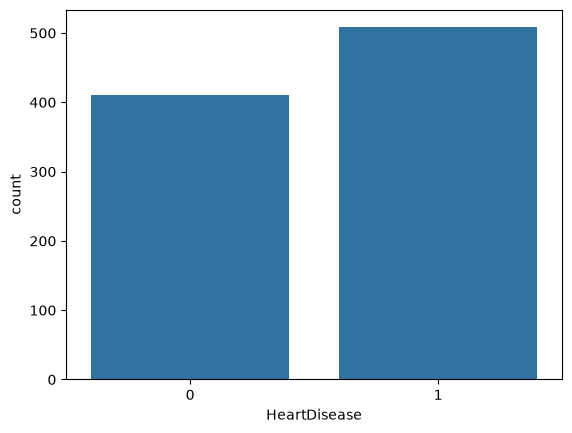

In [8]:
sb.countplot(x = df['HeartDisease'])

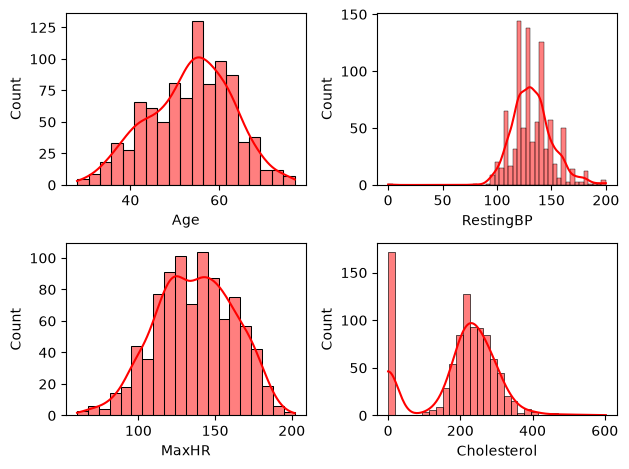

In [9]:
def vis(var, num):
    plt.subplot(2, 2, num)
    sb.histplot(df[var], kde = 1, color='red')

vis('Age', 1)
vis('RestingBP', 2)
vis('MaxHR', 3)
vis('Cholesterol', 4)

plt.tight_layout()

0 cholestrol and 0 restingBP isnt possible for any human being, hence making clear the data needs to be cleaned

In [10]:
#replacing both with their data domain mean/median

chol_median = df.loc[df['Cholesterol'] != 0, 'Cholesterol'].median()
rbp_mean = df.loc[df['RestingBP'] != 0, 'RestingBP'].mean()

df['Cholesterol'] = df['Cholesterol'].replace(0, chol_median)
df['RestingBP'] = df['RestingBP'].replace(0, rbp_mean)

df['Cholesterol'] = df['Cholesterol'].round(2)
df['RestingBP'] = df['RestingBP'].round(2)



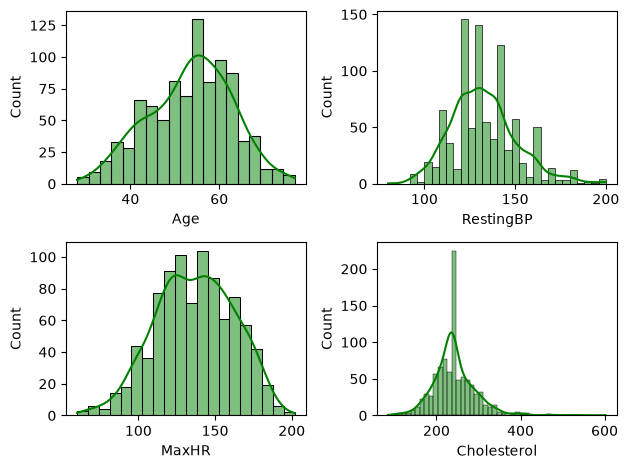

In [11]:
def vis(var, num):
    plt.subplot(2, 2, num)
    sb.histplot(df[var], kde = 1, color='green')

vis('Age', 1)
vis('RestingBP', 2)
vis('MaxHR', 3)
vis('Cholesterol', 4)

plt.tight_layout()

<Axes: xlabel='ChestPainType', ylabel='count'>

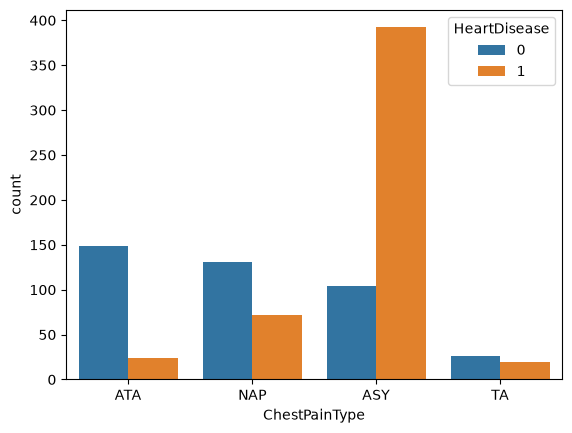

In [12]:
# checking affecting factors against categorical attributes
sb.countplot(x = df['ChestPainType'], hue = df['HeartDisease'])

<Axes: >

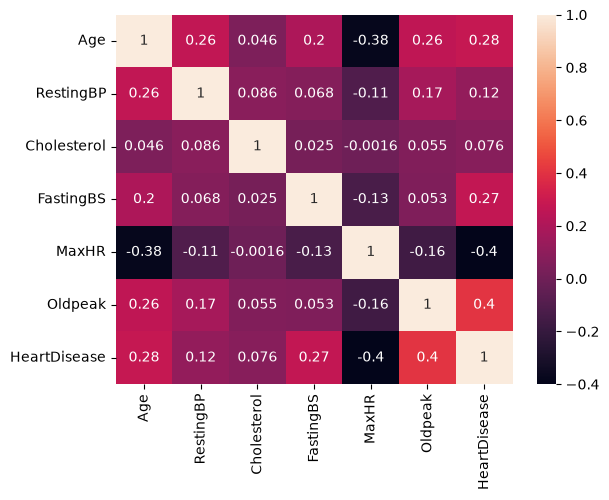

In [13]:
sb.heatmap(df.corr(numeric_only=True), annot=True)

In [ ]:
# DATA PREPROCESSING AND CLEANING ------------ at once

df_encode = pd.get_dummies(df)
df_encode = df_encode.astype(int)

df_encode

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_F,Sex_M,ChestPainType_ASY,...,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ExerciseAngina_N,ExerciseAngina_Y,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
0,40,140,289,0,172,0,0,0,1,0,...,0,0,0,1,0,1,0,0,0,1
1,49,160,180,0,156,1,1,1,0,0,...,1,0,0,1,0,1,0,0,1,0
2,37,130,283,0,98,0,0,0,1,0,...,0,0,0,0,1,1,0,0,0,1
3,48,138,214,0,108,1,1,1,0,1,...,0,0,0,1,0,0,1,0,1,0
4,54,150,195,0,122,0,0,0,1,0,...,1,0,0,1,0,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,110,264,0,132,1,1,0,1,0,...,0,1,0,1,0,1,0,0,1,0
914,68,144,193,1,141,3,1,0,1,1,...,0,0,0,1,0,1,0,0,1,0
915,57,130,131,0,115,1,1,0,1,1,...,0,0,0,1,0,0,1,0,1,0
916,57,130,236,0,174,0,1,1,0,0,...,0,0,1,0,0,1,0,0,1,0


In [17]:
# FEATURE SCALING

from sklearn.preprocessing import StandardScaler
cont_cols = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']

df_encode[cont_cols] = StandardScaler().fit_transform(df_encode[cont_cols])    #using STANDARDSCALAR CLASS & ITS METHOD
df_encode

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_F,Sex_M,ChestPainType_ASY,...,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ExerciseAngina_N,ExerciseAngina_Y,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
0,-1.433140,0.414885,0.858035,0,1.382928,-0.727592,0,0,1,0,...,0,0,0,1,0,1,0,0,0,1
1,-0.478484,1.527224,-1.184227,0,0.754157,0.282891,1,1,0,0,...,1,0,0,1,0,1,0,0,1,0
2,-1.751359,-0.141284,0.745617,0,-1.525138,-0.727592,0,0,1,0,...,0,0,0,0,1,1,0,0,0,1
3,-0.584556,0.303651,-0.547191,0,-1.132156,0.282891,1,1,0,1,...,0,0,0,1,0,0,1,0,1,0
4,0.051881,0.971054,-0.903182,0,-0.581981,-0.727592,0,0,1,0,...,1,0,0,1,0,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,-0.902775,-1.253622,0.389626,0,-0.188999,0.282891,1,0,1,0,...,0,1,0,1,0,1,0,0,1,0
914,1.536902,0.637353,-0.940654,1,0.164684,2.303858,1,0,1,1,...,0,0,0,1,0,1,0,0,1,0
915,0.370100,-0.141284,-2.102308,0,-0.857069,0.282891,1,0,1,1,...,0,0,0,1,0,0,1,0,1,0
916,0.370100,-0.141284,-0.134991,0,1.461525,-0.727592,1,1,0,0,...,0,0,1,0,0,1,0,0,1,0


In [ ]:
#Feature extraction and engineering

from scipy import pearson